In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/DSLAB_PROJECT/Database_ENG.dta"

df = pd.read_stata(path, convert_categoricals=False)

print(df.shape)
df.head()

Mounted at /content/drive
(4862, 219)


,qd1,qd7,qd7_a,qd2,qd3,qd5_1,qd5_2,qd5_3,qd5_4,qd5_5,...,qd6_2,qd6_3,qd6_4,qd6_5,qd6_6,qd6_7,qd9,qd12,qd13,wght
0,1,68,NaN,1,3,1,0,0,0,0,...,2,1,4,3,1,2,5,1,2,0.401783
1,1,36,NaN,4,2,0,0,1,0,0,...,1,2,2,3,2,1,5,1,-99,0.639130
2,0,64,NaN,4,3,0,1,0,0,0,...,3,3,3,2,2,2,5,1,-99,0.852871
3,0,50,NaN,4,4,0,0,0,0,1,...,2,2,2,2,2,2,1,1,-99,0.951568
4,1,66,NaN,4,3,0,1,0,0,0,...,3,1,4,4,2,2,7,1,1,0.945395


In [ ]:
qp8_vars = ["qp8_1", "qp8_2", "qp8_3", "qp8_4", "qp8_5"]

rq1_vars = [
    "qd1", "qd2", "qd3", "qd7", "qd7_a",
    "qd9", "qd10", "qd13", "qd14",
    *qp8_vars, "wght"
]

rq1 = df[rq1_vars].copy()

In [ ]:
rq1["internet_access"] = rq1["qd14"].where(
    rq1["qd14"].isin([0, 1]),
    np.nan
)

rq1["internet_access"].value_counts(dropna=False)

,count
internet_access,
1.0,4427
0.0,415
NaN,20


In [ ]:
qp8_clean = rq1[qp8_vars].where(
    rq1[qp8_vars].isin([0, 1])
)

at_least_one_yes = (qp8_clean == 1).any(axis=1)
all_valid_no = (
    qp8_clean.notna().all(axis=1)
    & (qp8_clean == 0).all(axis=1)
)

rq1["digital_adoption"] = np.select(
    [at_least_one_yes, all_valid_no],
    [1, 0],
    default=np.nan
)

# L'adozione viene analizzata soltanto tra chi ha Internet
rq1.loc[rq1["internet_access"] != 1, "digital_adoption"] = np.nan

rq1["digital_adoption"].value_counts(dropna=False)

,count
digital_adoption,
0.0,2849
1.0,1400
NaN,613


In [ ]:
age_exact = rq1["qd7"].replace(-99, np.nan)

rq1["age_group"] = pd.cut(
    age_exact,
    bins=[17, 29, 39, 49, 59, 69, np.inf],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
).astype("object")

age_band_map = {
    1: "18-29",
    2: "18-29",
    3: "30-39",
    4: "40-49",
    5: "50-59",
    6: "60-69",
    7: "70+"
}

missing_age = rq1["age_group"].isna()

rq1.loc[missing_age, "age_group"] = (
    rq1.loc[missing_age, "qd7_a"].map(age_band_map)
)

In [ ]:
rq1["education_group"] = np.select(
    [
        rq1["qd9"].isin([1, 2, 3, 4]),
        rq1["qd9"].isin([5, 6]),
        rq1["qd9"].isin([7, 8]),
        rq1["qd9"].isin([9, 10])
    ],
    [
        "Università",
        "Secondaria superiore",
        "Secondaria inferiore",
        "Primaria o meno"
    ],
    default=None
)

rq1["education_group"] = rq1["education_group"].astype("object")

In [ ]:
income_map = {
    1: "Fino a 1.750 euro",
    2: "1.751-2.900 euro",
    3: "Oltre 2.900 euro",
    -97: "Non dichiarato",
    -99: "Non dichiarato"
}

rq1["income_group"] = rq1["qd13"].map(income_map)

In [ ]:
def weighted_rate(data, outcome):
    valid = data[[outcome, "wght"]].dropna()
    return np.average(valid[outcome], weights=valid["wght"])

print("Accesso a Internet:",
      weighted_rate(rq1, "internet_access"))

internet_users = rq1[rq1["internet_access"] == 1]

print("Adozione tra utenti Internet:",
      weighted_rate(internet_users, "digital_adoption"))

Accesso a Internet: 0.8942240824644304
Adozione tra utenti Internet: 0.3107598394854307


In [ ]:
def weighted_rates_by_group(data, group, outcome):
    results = []

    for category, subset in data.groupby(group, observed=True):
        valid = subset[[outcome, "wght"]].dropna()

        if len(valid) > 0:
            rate = np.average(
                valid[outcome],
                weights=valid["wght"]
            )

            results.append({
                group: category,
                "weighted_rate": rate,
                "n": len(valid)
            })

    return pd.DataFrame(results)

age_access = weighted_rates_by_group(
    rq1, "age_group", "internet_access"
)

age_adoption = weighted_rates_by_group(
    internet_users, "age_group", "digital_adoption"
)

display(age_access)
display(age_adoption)

,age_group,weighted_rate,n
0,18-29,0.986629,566
1,30-39,0.992976,875
2,40-49,0.981366,877
3,50-59,0.948862,955
4,60-69,0.807242,835
5,70+,0.579169,734


,age_group,weighted_rate,n
0,18-29,0.205009,528
1,30-39,0.319657,835
2,40-49,0.410863,821
3,50-59,0.365649,882
4,60-69,0.266011,702
5,70+,0.192475,481


In [ ]:
import statsmodels.formula.api as smf

model_access_data = rq1.dropna(
    subset=[
        "internet_access",
        "age_group",
        "education_group",
        "qd1",
        "qd10",
        "qd2",
        "qd3"
    ]
)

formula_access = """
internet_access ~
C(age_group) +
C(education_group) +
C(qd1) +
C(qd10) +
C(qd2) +
C(qd3)
"""

model_access = smf.logit(
    formula_access,
    data=model_access_data
).fit(cov_type="HC1")

print(model_access.summary())

         Current function value: 0.191519
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        internet_access   No. Observations:                 4842
Model:                          Logit   Df Residuals:                     4815
Method:                           MLE   Df Model:                           26
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.3452
Time:                        14:47:38   Log-Likelihood:                -927.34
converged:                      False   LL-Null:                       -1416.3
Covariance Type:                  HC1   LLR p-value:                1.841e-189
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     19.6739     14.601      1.347     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
model_adoption_data = rq1[
    rq1["internet_access"] == 1
].dropna(
    subset=[
        "digital_adoption",
        "age_group",
        "education_group",
        "qd1",
        "qd10",
        "qd2",
        "qd3"
    ]
)

formula_adoption = """
digital_adoption ~
C(age_group) +
C(education_group) +
C(qd1) +
C(qd10) +
C(qd2) +
C(qd3)
"""

model_adoption = smf.logit(
    formula_adoption,
    data=model_adoption_data
).fit(cov_type="HC1")

print(model_adoption.summary())

Optimization terminated successfully.
         Current function value: 0.594062
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       digital_adoption   No. Observations:                 4249
Model:                          Logit   Df Residuals:                     4222
Method:                           MLE   Df Model:                           26
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.06272
Time:                        14:47:38   Log-Likelihood:                -2524.2
converged:                       True   LL-Null:                       -2693.1
Covariance Type:                  HC1   LLR p-value:                 5.288e-56
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                   

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1. Pulizia codici speciali
special_codes = [-99, -98, -97]

for var in ["qd1", "qd2", "qd3", "qd9", "qd10", "qd13"]:
    rq1[var] = rq1[var].replace(special_codes, np.nan)

# 2. Condizione lavorativa aggregata
work_map = {
    1: "Occupato",
    2: "Occupato",
    3: "Occupato",
    4: "Non occupato",
    5: "Non occupato",
    6: "Pensionato",
    7: "Non occupato",
    8: "Non occupato",
    9: "Non occupato",
    10: "Non occupato"
}

rq1["work_group"] = rq1["qd10"].map(work_map)

# 3. Urbanizzazione aggregata
urban_map = {
    1: "Rurale",
    2: "Piccolo centro",
    3: "Centro medio",
    4: "Grande centro",
    5: "Grande centro"
}

rq1["urban_group"] = rq1["qd3"].map(urban_map)

# 4. Campione completo
required_vars = [
    "internet_access",
    "age_group",
    "education_group",
    "qd1",
    "work_group",
    "qd2",
    "urban_group"
]

model_access_data = rq1.dropna(
    subset=required_vars
).copy()

# 5. Formula con riferimenti espliciti
formula_access = """
internet_access ~
C(age_group, Treatment(reference="18-29")) +
C(education_group, Treatment(reference="Primaria o meno")) +
C(qd1, Treatment(reference=0)) +
C(work_group, Treatment(reference="Occupato")) +
C(qd2, Treatment(reference=1)) +
C(urban_group, Treatment(reference="Rurale"))
"""

# 6. Stima
model_access = smf.logit(
    formula_access,
    data=model_access_data
).fit(
    method="lbfgs",
    maxiter=1000,
    cov_type="HC1"
)

print(model_access.summary())
print("\nConvergenza:", model_access.mle_retvals["converged"])

# 7. Odds ratio
conf = model_access.conf_int()

or_table = pd.DataFrame({
    "OR": np.exp(model_access.params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": model_access.pvalues
})

display(or_table.round(3))

# 8. Effetti marginali
marginal_effects = model_access.get_margeff(at="overall")
print(marginal_effects.summary())

                           Logit Regression Results                           
Dep. Variable:        internet_access   No. Observations:                 4823
Model:                          Logit   Df Residuals:                     4804
Method:                           MLE   Df Model:                           18
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.3437
Time:                        14:47:38   Log-Likelihood:                -928.32
converged:                       True   LL-Null:                       -1414.6
Covariance Type:                  HC1   LLR p-value:                5.352e-195
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                         

,OR,CI_low,CI_high,p_value
Intercept,6.266,2.271,17.286,0.000
"C(age_group, Treatment(reference=""18-29""))[T.30-39]",1.377,0.417,4.541,0.599
"C(age_group, Treatment(reference=""18-29""))[T.40-49]",0.517,0.205,1.304,0.162
"C(age_group, Treatment(reference=""18-29""))[T.50-59]",0.300,0.130,0.692,0.005
"C(age_group, Treatment(reference=""18-29""))[T.60-69]",0.150,0.067,0.335,0.000
"C(age_group, Treatment(reference=""18-29""))[T.70+]",0.072,0.032,0.165,0.000
"C(education_group, Treatment(reference=""Primaria o meno""))[T.Secondaria inferiore]",2.802,1.732,4.534,0.000
"C(education_group, Treatment(reference=""Primaria o meno""))[T.Secondaria superiore]",11.824,7.307,19.134,0.000
"C(education_group, Treatment(reference=""Primaria o meno""))[T.Università]",28.198,14.275,55.700,0.000
"C(qd1, Treatment(reference=0))[T.1]",1.246,0.970,1.601,0.085


        Logit Marginal Effects       
Dep. Variable:        internet_access
Method:                          dydx
At:                           overall
                                                                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
C(age_group, Treatment(reference="18-29"))[T.30-39]                                    0.0178      0.034      0.525      0.599      -0.049       0.084
C(age_group, Treatment(reference="18-29"))[T.40-49]                                   -0.0368      0.026     -1.395      0.163      -0.088       0.015
C(age_group, Treatment(reference="18-29"))[T.50-59]                                   -0.0671      0.024     -2.821      0.005      -0.114      -0.020
C(age_group, Treatment(reference="18-29"))[T.60-69]                                   -0.1059

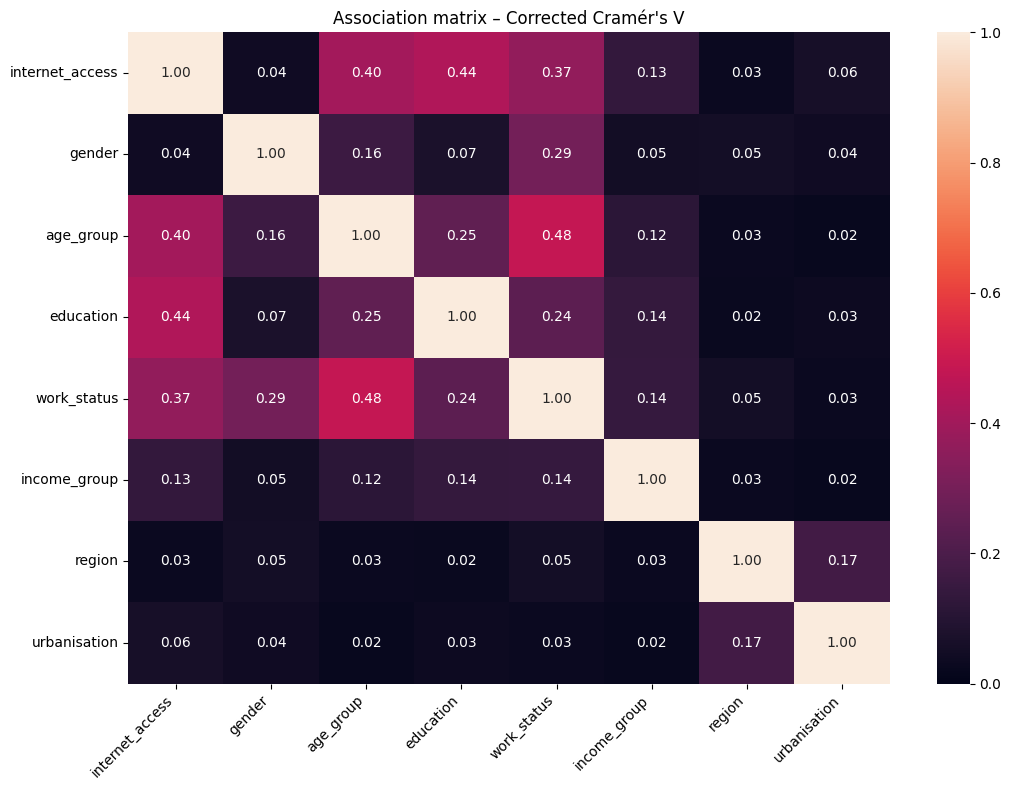

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
file_path = "/content/drive/MyDrive/DSLAB_PROJECT/RQ1_Internet_Access_Results/RQ1_internet_access_clean.csv"

df = pd.read_csv(file_path)

# Campione valido per l'analisi dell'accesso
access_df = df[df["internet_access"].isin([0, 1])].copy()

variables = [
    "internet_access",
    "gender",
    "age_group",
    "education",
    "work_status",
    "income_group",
    "region",
    "urbanisation"
]

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(
        table,
        correction=False
    )[0]

    n = table.to_numpy().sum()
    phi2 = chi2 / n

    r, k = table.shape

    # Correzione del bias
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(r_corr - 1, k_corr - 1)

    return np.sqrt(phi2_corr / denominator) if denominator > 0 else 0


association_matrix = pd.DataFrame(
    index=variables,
    columns=variables,
    dtype=float
)

for row_variable in variables:
    for column_variable in variables:
        if row_variable == column_variable:
            association_matrix.loc[row_variable, column_variable] = 1
        else:
            valid = access_df[
                [row_variable, column_variable]
            ].dropna()

            association_matrix.loc[
                row_variable,
                column_variable
            ] = cramers_v(
                valid[row_variable],
                valid[column_variable]
            )

plt.figure(figsize=(11, 8))

sns.heatmap(
    association_matrix,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)

plt.title("Association matrix – Corrected Cramér's V")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
predictors = [
    "gender",
    "age_group",
    "education",
    "work_status",
    "income_group",
    "region",
    "urbanisation"
]

ranking = pd.Series({
    variable: cramers_v(
        access_df[variable],
        access_df["internet_access"]
    )
    for variable in predictors
}).sort_values(ascending=False)

print(ranking)

education       0.436887
age_group       0.403796
work_status     0.365271
income_group    0.133174
urbanisation    0.058663
gender          0.039346
region          0.030686
dtype: float64


seconda parte

In [17]:
from pathlib import Path
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# Cartella indicata nel tuo messaggio
PROJECT_DIR = Path(
    "/content/drive/MyDrive/DSLAB_PROJECT/RQ1_secondpart"
)

# Cartelle nelle quali saranno salvati i risultati
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

for folder in [
    PROJECT_DIR,
    OUTPUT_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Cartella del progetto:", PROJECT_DIR)
print("Cartella dei risultati:", OUTPUT_DIR)

Cartella del progetto: /content/drive/MyDrive/DSLAB_PROJECT/RQ1_secondpart
Cartella dei risultati: /content/drive/MyDrive/DSLAB_PROJECT/RQ1_secondpart/outputs


In [18]:
csv_candidates = sorted(
    PROJECT_DIR.glob(
        "RQ1_internet_access_clean_with_qp8_qp9.csv"
    )
)

if len(csv_candidates) == 0:
    raise FileNotFoundError(
        "Non è stato trovato nessun CSV con nome "
        "'RQ1_internet_access_clean_with_qp8_qp9.csv' "
        f"nella cartella:\n{PROJECT_DIR}"
    )

print("File CSV trovati:")

for position, file in enumerate(csv_candidates, start=1):
    print(position, file.name)

# Prende il primo file trovato
INPUT_FILE = csv_candidates[0]

print("\nFile utilizzato:")
print(INPUT_FILE)

File CSV trovati:
1 RQ1_internet_access_clean_with_qp8_qp9.csv

File utilizzato:
/content/drive/MyDrive/DSLAB_PROJECT/RQ1_secondpart/RQ1_internet_access_clean_with_qp8_qp9.csv


In [25]:
df = pd.read_csv(INPUT_FILE)

print("Dimensione del dataset:", df.shape)
print("Numero di righe:", len(df))
print("Numero di colonne:", df.shape[1])

display(df.head())

Dimensione del dataset: (4862, 31)
Numero di righe: 4862
Numero di colonne: 31


,qd1,qd2,qd3,qd7,qd7_a,qd9,qd10,qd13,qd14,wght,...,qp8_3,qp8_4,qp8_5,qp9_1,qp9_3,qp9_4,qp9_5,qp9_6,qp9_7,qp9_10
0,1,1,3,68,NaN,5,6,2,1,0.401783,...,0.0,0.0,0.0,4.0,4.0,3.0,1.0,1.0,1.0,1.0
1,1,4,2,36,NaN,5,2,-99,1,0.639130,...,0.0,0.0,0.0,3.0,1.0,1.0,4.0,2.0,1.0,3.0
2,0,4,3,64,NaN,5,4,-99,1,0.852871,...,-97.0,-98.0,-97.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0
3,0,4,4,50,NaN,1,1,-99,1,0.951568,...,0.0,0.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,1,4,3,66,NaN,7,6,1,1,0.945395,...,0.0,0.0,0.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0


In [26]:
qp8_cols = [
    "qp8_1",
    "qp8_2",
    "qp8_3",
    "qp8_4",
    "qp8_5"
]

qp9_cols = [
    "qp9_1",
    "qp9_3",
    "qp9_4",
    "qp9_5",
    "qp9_6",
    "qp9_7",
    "qp9_10"
]

required_columns = [
    "internet_access",
    "age_group",
    "education",
    "wght"
] + qp8_cols + qp9_cols

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "Nel CSV mancano le seguenti colonne:\n"
        + "\n".join(missing_columns)
    )

print("Tutte le colonne necessarie sono presenti.")

Tutte le colonne necessarie sono presenti.


In [27]:
qp8_labels = {
    "qp8_1": "Apertura conto",
    "qp8_2": "Richiesta carta",
    "qp8_3": "Assicurazione",
    "qp8_4": "Credito",
    "qp8_5": "Investimento tramite piattaforma"
}

qp9_labels = {
    "qp9_1": "Saldo e transazioni",
    "qp9_3": "Pagamento bollette",
    "qp9_4": "Acquisti online",
    "qp9_5": "Trasferimenti di denaro",
    "qp9_6": "Gestione prodotti finanziari",
    "qp9_7": "Pagamenti con smartphone",
    "qp9_10": "Robo-advisor"
}

qp9_response_labels = {
    1: "Never",
    2: "Sometimes",
    3: "Often",
    4: "Very often"
}

In [28]:
age_order = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]

education_map = {
    "Primaria o inferiore":
        "Secondaria inferiore o meno",

    "Secondaria inferiore":
        "Secondaria inferiore o meno",

    "Secondaria superiore":
        "Secondaria superiore",

    "Università":
        "Università"
}

education_order = [
    "Secondaria inferiore o meno",
    "Secondaria superiore",
    "Università"
]

df["education_model"] = (
    df["education"]
    .map(education_map)
)

df["age_group"] = pd.Categorical(
    df["age_group"],
    categories=age_order,
    ordered=True
)

df["education_model"] = pd.Categorical(
    df["education_model"],
    categories=education_order,
    ordered=True
)

print("Fasce d'età:")
print(df["age_group"].value_counts(dropna=False).sort_index())

print("\nLivelli di istruzione:")
print(
    df["education_model"]
    .value_counts(dropna=False)
    .sort_index()
)

Fasce d'età:
age_group
18-29    567
30-39    880
40-49    880
50-59    958
60-69    841
70+      736
Name: count, dtype: int64

Livelli di istruzione:
education_model
Secondaria inferiore o meno     727
Secondaria superiore           2856
Università                     1279
Name: count, dtype: int64


In [33]:
qp8_data = connected[qp8_cols]

at_least_one_qp8_yes = (
    qp8_data.eq(1)
    .any(axis=1)
)

all_qp8_observed = (
    qp8_data
    .notna()
    .all(axis=1)
)

all_qp8_no = (
    qp8_data.eq(0)
    .all(axis=1)
)

connected["digital_adoption"] = np.select(
    condlist=[
        at_least_one_qp8_yes,
        all_qp8_observed & all_qp8_no
    ],
    choicelist=[
        1,
        0
    ],
    default=np.nan
)

In [34]:
connected["qp8_number_services"] = (
    qp8_data
    .eq(1)
    .sum(axis=1)
)

connected["qp8_number_services"] = (
    connected["qp8_number_services"]
    .where(
        qp8_data.notna().any(axis=1)
    )
)

In [35]:
print(
    connected["digital_adoption"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nNumero di attività QP8 dichiarate:")

print(
    connected["qp8_number_services"]
    .value_counts(dropna=False)
    .sort_index()
)

digital_adoption
0.0    2849
1.0    1400
NaN     178
Name: count, dtype: int64

Numero di attività QP8 dichiarate:
qp8_number_services
0.0    2938
1.0     722
2.0     450
3.0     143
4.0      68
5.0      17
NaN      89
Name: count, dtype: int64


In [36]:
qp9_data = connected[qp9_cols]

at_least_one_frequent_activity = (
    qp9_data
    .isin([3, 4])
    .any(axis=1)
)

all_qp9_observed = (
    qp9_data
    .notna()
    .all(axis=1)
)

no_frequent_activity = (
    qp9_data
    .isin([1, 2])
    .all(axis=1)
)

connected["any_frequent_qp9"] = np.select(
    condlist=[
        at_least_one_frequent_activity,
        all_qp9_observed & no_frequent_activity
    ],
    choicelist=[
        1,
        0
    ],
    default=np.nan
)

In [37]:
connected["qp9_frequent_count"] = (
    qp9_data
    .isin([3, 4])
    .sum(axis=1)
)

connected["qp9_valid_count"] = (
    qp9_data
    .notna()
    .sum(axis=1)
)

In [38]:
connected["qp9_mean_score"] = (
    qp9_data
    .mean(axis=1)
    .where(
        connected["qp9_valid_count"] >= 4
    )
)

In [39]:
print(
    connected["any_frequent_qp9"]
    .value_counts(dropna=False)
    .sort_index()
)

display(
    connected[
        [
            "qp9_frequent_count",
            "qp9_valid_count",
            "qp9_mean_score"
        ]
    ].describe()
)

any_frequent_qp9
0.0     944
1.0    3307
NaN     176
Name: count, dtype: int64


,qp9_frequent_count,qp9_valid_count,qp9_mean_score
count,4427.000000,4427.000000,4240.000000
mean,2.347414,6.667495,2.067091
std,1.993305,1.285372,0.674236
min,0.000000,0.000000,1.000000
25%,0.000000,7.000000,1.571429
50%,2.000000,7.000000,2.000000
75%,4.000000,7.000000,2.571429
max,7.000000,7.000000,4.000000


In [40]:
analysis_data_path = (
    OUTPUT_DIR
    / "RQ1_secondpart_analysis_ready.csv"
)

connected.to_csv(
    analysis_data_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset analitico salvato in:")
print(analysis_data_path)

Dataset analitico salvato in:
/content/drive/MyDrive/DSLAB_PROJECT/RQ1_secondpart/outputs/RQ1_secondpart_analysis_ready.csv


In [41]:
def weighted_average(values, weights):
    """
    Calcola una media ponderata dopo aver eliminato
    valori e pesi mancanti.
    """

    values = pd.to_numeric(
        values,
        errors="coerce"
    )

    weights = pd.to_numeric(
        weights,
        errors="coerce"
    )

    valid = (
        values.notna()
        & weights.notna()
        & weights.gt(0)
    )

    if valid.sum() == 0:
        return np.nan

    return np.average(
        values[valid],
        weights=weights[valid]
    )


def weighted_percentage(values, weights):
    """
    Media ponderata di una variabile binaria,
    espressa in percentuale.
    """

    result = weighted_average(
        values,
        weights
    )

    if pd.isna(result):
        return np.nan

    return result * 100

In [42]:
def composite_group_summary(data, group_variable):

    records = []

    grouped_data = data.groupby(
        group_variable,
        observed=False
    )

    for category, group in grouped_data:

        adoption_valid = (
            group["digital_adoption"]
            .isin([0, 1])
            & group["wght"].notna()
        )

        frequent_valid = (
            group["any_frequent_qp9"]
            .isin([0, 1])
            & group["wght"].notna()
        )

        records.append({
            "category": str(category),

            "n_connected":
                len(group),

            "n_valid_adoption":
                int(adoption_valid.sum()),

            "adopters":
                int(
                    group.loc[
                        adoption_valid,
                        "digital_adoption"
                    ].sum()
                ),

            "weighted_adoption_pct":
                weighted_percentage(
                    group.loc[
                        adoption_valid,
                        "digital_adoption"
                    ],
                    group.loc[
                        adoption_valid,
                        "wght"
                    ]
                ),

            "n_valid_frequent_qp9":
                int(frequent_valid.sum()),

            "weighted_any_frequent_qp9_pct":
                weighted_percentage(
                    group.loc[
                        frequent_valid,
                        "any_frequent_qp9"
                    ],
                    group.loc[
                        frequent_valid,
                        "wght"
                    ]
                )
        })

    return pd.DataFrame(records)

In [43]:
age_composite = composite_group_summary(
    connected,
    "age_group"
)

education_composite = composite_group_summary(
    connected,
    "education_model"
)

age_composite["category"] = pd.Categorical(
    age_composite["category"],
    categories=age_order,
    ordered=True
)

education_composite["category"] = pd.Categorical(
    education_composite["category"],
    categories=education_order,
    ordered=True
)

age_composite = (
    age_composite
    .sort_values("category")
    .reset_index(drop=True)
)

education_composite = (
    education_composite
    .sort_values("category")
    .reset_index(drop=True)
)

print("Sintesi per età:")
display(age_composite.round(2))

print("Sintesi per istruzione:")
display(education_composite.round(2))

Sintesi per età:


,category,n_connected,n_valid_adoption,adopters,weighted_adoption_pct,n_valid_frequent_qp9,weighted_any_frequent_qp9_pct
0,18-29,559,528,112,20.50,479,69.91
1,30-39,870,835,277,31.97,850,87.65
2,40-49,863,821,352,41.09,844,82.96
3,50-59,923,882,352,36.56,893,76.70
4,60-69,722,702,202,26.60,708,64.38
5,70+,490,481,105,19.25,477,49.09


Sintesi per istruzione:


,category,n_connected,n_valid_adoption,adopters,weighted_adoption_pct,n_valid_frequent_qp9,weighted_any_frequent_qp9_pct
0,Secondaria inferiore o meno,463,435,61,15.74,426,49.04
1,Secondaria superiore,2705,2597,826,31.48,2594,77.24
2,Università,1259,1217,513,41.43,1231,88.81


In [44]:
def qp8_item_summary(data, group_variable):

    records = []

    for category, group in data.groupby(
        group_variable,
        observed=False
    ):

        for column, activity_label in qp8_labels.items():

            valid = (
                group[column].isin([0, 1])
                & group["wght"].notna()
            )

            if valid.sum() == 0:
                yes_percentage = np.nan
            else:
                yes_percentage = weighted_percentage(
                    group.loc[valid, column],
                    group.loc[valid, "wght"]
                )

            records.append({
                "group_variable": group_variable,
                "category": str(category),
                "variable": column,
                "activity": activity_label,
                "n_valid": int(valid.sum()),
                "weighted_yes_pct": yes_percentage,
                "weighted_no_pct":
                    100 - yes_percentage
                    if pd.notna(yes_percentage)
                    else np.nan
            })

    return pd.DataFrame(records)

In [45]:
qp8_by_age = qp8_item_summary(
    connected,
    "age_group"
)

qp8_by_education = qp8_item_summary(
    connected,
    "education_model"
)

qp8_results = pd.concat(
    [
        qp8_by_age,
        qp8_by_education
    ],
    ignore_index=True
)

qp8_results.to_csv(
    TABLES_DIR
    / "QP8_weighted_results_by_age_education.csv",
    index=False,
    encoding="utf-8-sig"
)

In [46]:
qp8_age_pivot = (
    qp8_by_age
    .pivot(
        index="category",
        columns="activity",
        values="weighted_yes_pct"
    )
    .reindex(age_order)
)

qp8_education_pivot = (
    qp8_by_education
    .pivot(
        index="category",
        columns="activity",
        values="weighted_yes_pct"
    )
    .reindex(education_order)
)

print("QP8 per età:")
display(qp8_age_pivot.round(1))

print("QP8 per istruzione:")
display(qp8_education_pivot.round(1))

QP8 per età:


activity,Apertura conto,Assicurazione,Credito,Investimento tramite piattaforma,Richiesta carta
category,,,,,
18-29,13.2,6.3,3.9,0.8,11.8
30-39,20.2,15.3,5.5,2.1,17.4
40-49,21.0,18.6,7.0,3.3,22.8
50-59,17.6,17.6,4.7,1.3,16.0
60-69,10.5,14.0,5.0,1.6,10.4
70+,10.7,11.1,3.3,1.5,6.6


QP8 per istruzione:


activity,Apertura conto,Assicurazione,Credito,Investimento tramite piattaforma,Richiesta carta
category,,,,,
Secondaria inferiore o meno,8.9,5.3,2.5,1.4,7.9
Secondaria superiore,16.8,14.3,5.6,1.6,13.2
Università,21.3,21.6,6.1,2.6,25.2


In [47]:
def qp9_item_summary(data, group_variable):

    records = []

    for category, group in data.groupby(
        group_variable,
        observed=False
    ):

        for column, activity_label in qp9_labels.items():

            valid = (
                group[column].isin([1, 2, 3, 4])
                & group["wght"].notna()
            )

            values = group.loc[valid, column]
            weights = group.loc[valid, "wght"]

            if valid.sum() == 0:

                at_least_sometimes = np.nan
                frequent = np.nan
                mean_score = np.nan

            else:

                at_least_sometimes = (
                    weighted_percentage(
                        values.ge(2).astype(int),
                        weights
                    )
                )

                frequent = weighted_percentage(
                    values.ge(3).astype(int),
                    weights
                )

                mean_score = weighted_average(
                    values,
                    weights
                )

            records.append({
                "group_variable": group_variable,
                "category": str(category),
                "variable": column,
                "activity": activity_label,
                "n_valid": int(valid.sum()),

                "weighted_at_least_sometimes_pct":
                    at_least_sometimes,

                "weighted_often_or_very_often_pct":
                    frequent,

                "weighted_mean_1_4":
                    mean_score
            })

    return pd.DataFrame(records)

In [48]:
qp9_by_age = qp9_item_summary(
    connected,
    "age_group"
)

qp9_by_education = qp9_item_summary(
    connected,
    "education_model"
)

qp9_results = pd.concat(
    [
        qp9_by_age,
        qp9_by_education
    ],
    ignore_index=True
)

qp9_results.to_csv(
    TABLES_DIR
    / "QP9_weighted_results_by_age_education.csv",
    index=False,
    encoding="utf-8-sig"
)

In [49]:
qp9_age_frequent_pivot = (
    qp9_by_age
    .pivot(
        index="category",
        columns="activity",
        values="weighted_often_or_very_often_pct"
    )
    .reindex(age_order)
)

qp9_education_frequent_pivot = (
    qp9_by_education
    .pivot(
        index="category",
        columns="activity",
        values="weighted_often_or_very_often_pct"
    )
    .reindex(education_order)
)

print("QP9: Often o Very often per età")
display(qp9_age_frequent_pivot.round(1))

print("QP9: Often o Very often per istruzione")
display(qp9_education_frequent_pivot.round(1))

QP9: Often o Very often per età


activity,Acquisti online,Gestione prodotti finanziari,Pagamenti con smartphone,Pagamento bollette,Robo-advisor,Saldo e transazioni,Trasferimenti di denaro
category,,,,,,,
18-29,43.3,16.4,24.3,36.2,11.0,55.8,20.6
30-39,55.4,19.2,29.1,64.7,16.3,78.4,25.7
40-49,53.9,21.8,31.4,60.1,21.9,70.9,26.5
50-59,42.3,18.2,22.3,52.4,15.4,63.6,22.9
60-69,24.4,13.7,14.0,40.3,13.0,52.7,14.0
70+,19.5,9.7,15.3,31.5,14.5,34.2,15.9


QP9: Often o Very often per istruzione


activity,Acquisti online,Gestione prodotti finanziari,Pagamenti con smartphone,Pagamento bollette,Robo-advisor,Saldo e transazioni,Trasferimenti di denaro
category,,,,,,,
Secondaria inferiore o meno,20.9,7.8,13.7,32.1,9.7,36.4,10.6
Secondaria superiore,44.1,19.0,23.8,51.3,16.7,63.6,22.9
Università,55.8,21.2,31.5,62.8,18.4,79.9,27.6


tutte non solo often e very often

In [50]:
def qp9_full_distribution(data, group_variable):

    records = []

    for category, group in data.groupby(
        group_variable,
        observed=False
    ):

        for column, activity_label in qp9_labels.items():

            valid = (
                group[column].isin([1, 2, 3, 4])
                & group["wght"].notna()
            )

            valid_group = group.loc[valid]

            total_weight = (
                valid_group["wght"].sum()
            )

            for response_code in [1, 2, 3, 4]:

                response_weight = (
                    valid_group.loc[
                        valid_group[column].eq(
                            response_code
                        ),
                        "wght"
                    ].sum()
                )

                percentage = (
                    100
                    * response_weight
                    / total_weight
                    if total_weight > 0
                    else np.nan
                )

                records.append({
                    "group_variable":
                        group_variable,

                    "category":
                        str(category),

                    "variable":
                        column,

                    "activity":
                        activity_label,

                    "response_code":
                        response_code,

                    "response_label":
                        qp9_response_labels[
                            response_code
                        ],

                    "n_valid":
                        int(valid.sum()),

                    "weighted_percentage":
                        percentage
                })

    return pd.DataFrame(records)

In [52]:
qp9_distribution_age = qp9_full_distribution(
    connected,
    "age_group"
)

qp9_distribution_education = qp9_full_distribution(
    connected,
    "education_model"
)

qp9_full_results = pd.concat(
    [
        qp9_distribution_age,
        qp9_distribution_education
    ],
    ignore_index=True
)

qp9_full_results.to_csv(
    TABLES_DIR
    / "QP9_full_response_distribution.csv",
    index=False,
    encoding="utf-8-sig"
)

display(qp9_full_results.round(2))

,group_variable,category,variable,activity,response_code,response_label,n_valid,weighted_percentage
0,age_group,18-29,qp9_1,Saldo e transazioni,1,Never,490,17.53
1,age_group,18-29,qp9_1,Saldo e transazioni,2,Sometimes,490,26.63
2,age_group,18-29,qp9_1,Saldo e transazioni,3,Often,490,37.30
3,age_group,18-29,qp9_1,Saldo e transazioni,4,Very often,490,18.54
4,age_group,18-29,qp9_3,Pagamento bollette,1,Never,458,44.38
...,...,...,...,...,...,...,...,...
247,education_model,Università,qp9_7,Pagamenti con smartphone,4,Very often,1219,9.16
248,education_model,Università,qp9_10,Robo-advisor,1,Never,1210,65.03
249,education_model,Università,qp9_10,Robo-advisor,2,Sometimes,1210,16.57
250,education_model,Università,qp9_10,Robo-advisor,3,Often,1210,13.66


grafici

In [54]:
def save_annotated_heatmap(
    table,
    title,
    colorbar_label,
    output_path,
    percentage=True
):

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    matrix = table.to_numpy(
        dtype=float
    )

    image = ax.imshow(
        matrix,
        aspect="auto"
    )

    ax.set_xticks(
        range(table.shape[1])
    )

    ax.set_xticklabels(
        table.columns,
        rotation=40,
        ha="right"
    )

    ax.set_yticks(
        range(table.shape[0])
    )

    ax.set_yticklabels(
        table.index
    )

    ax.set_title(title)

    for row in range(table.shape[0]):

        for column in range(table.shape[1]):

            value = table.iloc[
                row,
                column
            ]

            if pd.notna(value):

                label = (
                    f"{value:.1f}%"
                    if percentage
                    else f"{value:.2f}"
                )

                ax.text(
                    column,
                    row,
                    label,
                    ha="center",
                    va="center"
                )

    colorbar = fig.colorbar(
        image,
        ax=ax
    )

    colorbar.set_label(
        colorbar_label
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

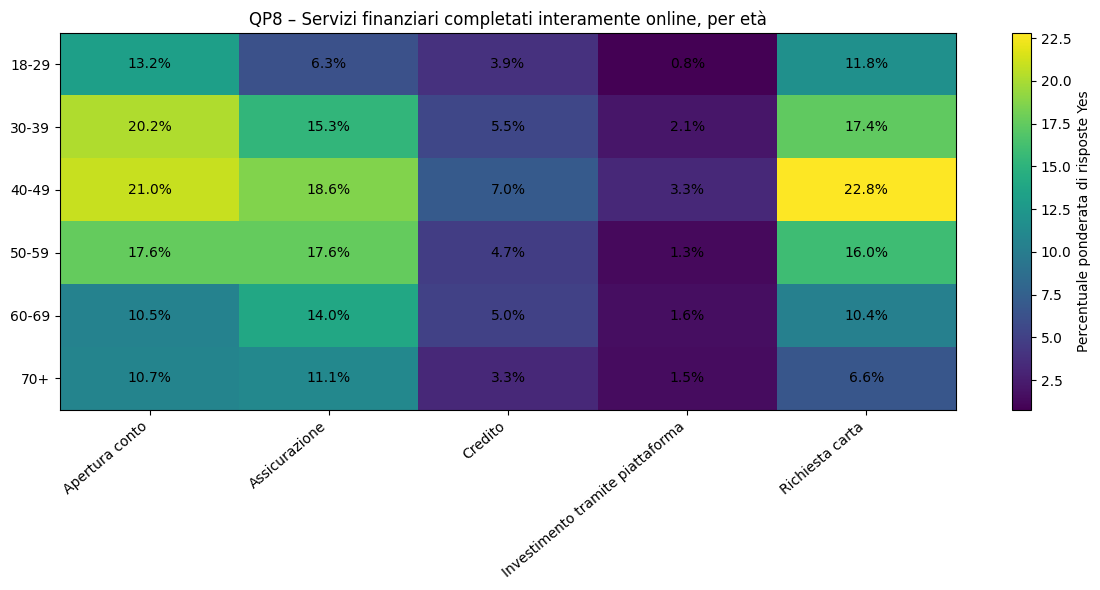

In [55]:
save_annotated_heatmap(
    table=qp8_age_pivot,

    title=(
        "QP8 – Servizi finanziari completati "
        "interamente online, per età"
    ),

    colorbar_label=(
        "Percentuale ponderata di risposte Yes"
    ),

    output_path=(
        FIGURES_DIR
        / "QP8_by_age.png"
    )
)

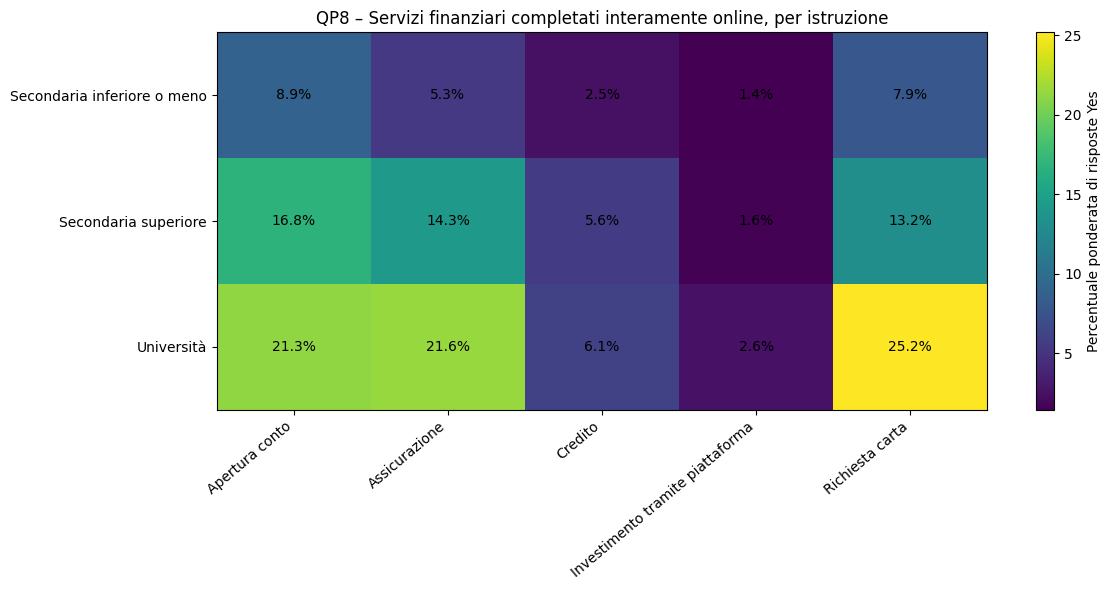

In [56]:
save_annotated_heatmap(
    table=qp8_education_pivot,

    title=(
        "QP8 – Servizi finanziari completati "
        "interamente online, per istruzione"
    ),

    colorbar_label=(
        "Percentuale ponderata di risposte Yes"
    ),

    output_path=(
        FIGURES_DIR
        / "QP8_by_education.png"
    )
)

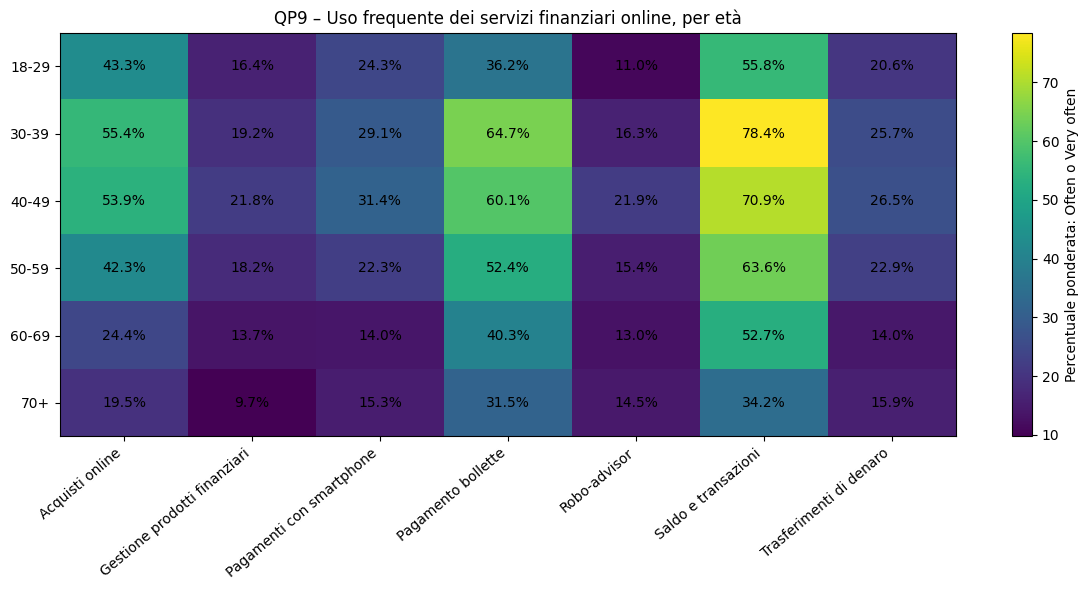

In [57]:
save_annotated_heatmap(
    table=qp9_age_frequent_pivot,

    title=(
        "QP9 – Uso frequente dei servizi "
        "finanziari online, per età"
    ),

    colorbar_label=(
        "Percentuale ponderata: Often "
        "o Very often"
    ),

    output_path=(
        FIGURES_DIR
        / "QP9_frequent_by_age.png"
    )
)

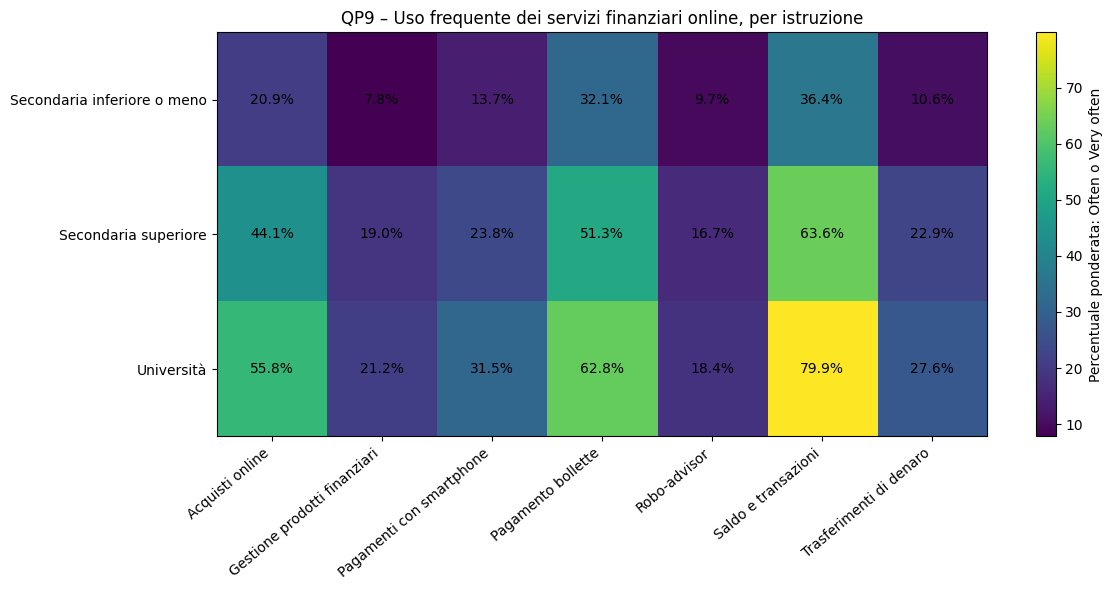

In [58]:
save_annotated_heatmap(
    table=qp9_education_frequent_pivot,

    title=(
        "QP9 – Uso frequente dei servizi "
        "finanziari online, per istruzione"
    ),

    colorbar_label=(
        "Percentuale ponderata: Often "
        "o Very often"
    ),

    output_path=(
        FIGURES_DIR
        / "QP9_frequent_by_education.png"
    )
)

In [59]:
def plot_composite_rates(
    summary_table,
    title,
    output_path
):

    plot_data = (
        summary_table
        .set_index("category")
        [
            [
                "weighted_adoption_pct",
                "weighted_any_frequent_qp9_pct"
            ]
        ]
        .copy()
    )

    plot_data.columns = [
        "Almeno un servizio QP8",
        "Almeno un'attività QP9 frequente"
    ]

    ax = plot_data.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Percentuale ponderata")
    ax.set_ylim(0, 100)

    ax.tick_params(
        axis="x",
        rotation=35
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=2
        )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

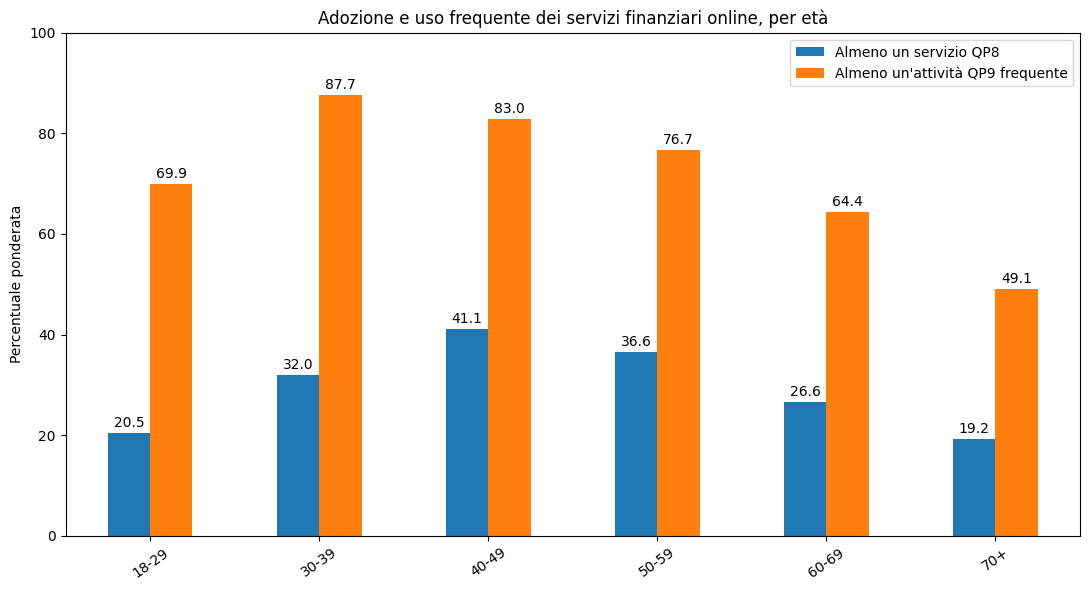

In [60]:
plot_composite_rates(
    summary_table=age_composite,

    title=(
        "Adozione e uso frequente dei "
        "servizi finanziari online, per età"
    ),

    output_path=(
        FIGURES_DIR
        / "composite_rates_by_age.png"
    )
)

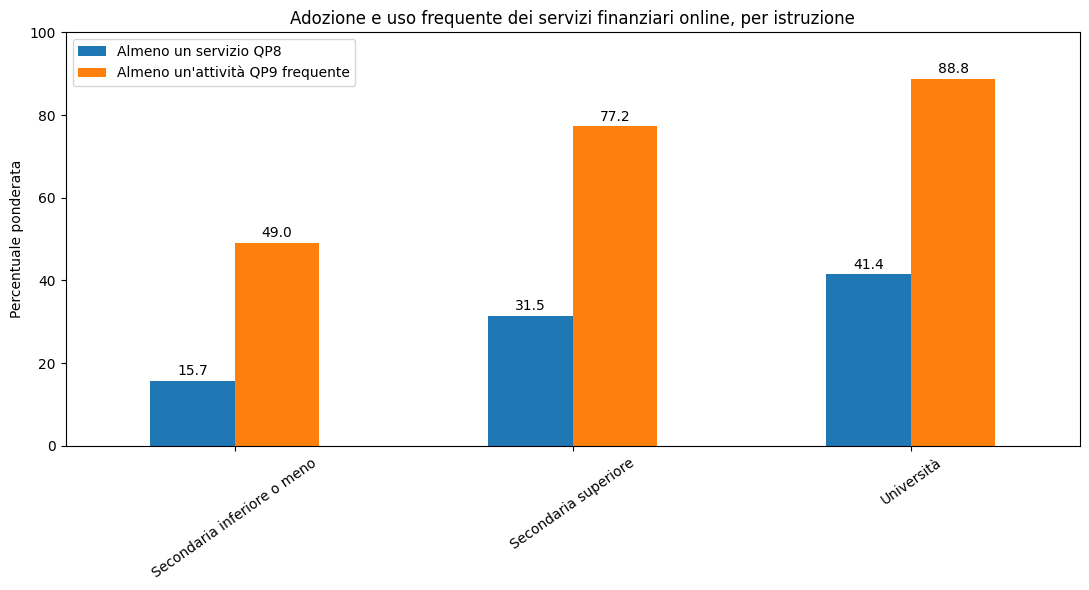

In [61]:
plot_composite_rates(
    summary_table=education_composite,

    title=(
        "Adozione e uso frequente dei "
        "servizi finanziari online, per istruzione"
    ),

    output_path=(
        FIGURES_DIR
        / "composite_rates_by_education.png"
    )
)

In [62]:
def age_education_summary(data):

    records = []

    groups = data.groupby(
        [
            "age_group",
            "education_model"
        ],
        observed=False
    )

    for (
        age_category,
        education_category
    ), group in groups:

        adoption_valid = (
            group["digital_adoption"]
            .isin([0, 1])
            & group["wght"].notna()
        )

        frequent_valid = (
            group["any_frequent_qp9"]
            .isin([0, 1])
            & group["wght"].notna()
        )

        records.append({
            "age_group":
                str(age_category),

            "education_model":
                str(education_category),

            "n_connected":
                len(group),

            "n_valid_adoption":
                int(adoption_valid.sum()),

            "weighted_adoption_pct":
                weighted_percentage(
                    group.loc[
                        adoption_valid,
                        "digital_adoption"
                    ],
                    group.loc[
                        adoption_valid,
                        "wght"
                    ]
                ),

            "n_valid_frequent_qp9":
                int(frequent_valid.sum()),

            "weighted_any_frequent_qp9_pct":
                weighted_percentage(
                    group.loc[
                        frequent_valid,
                        "any_frequent_qp9"
                    ],
                    group.loc[
                        frequent_valid,
                        "wght"
                    ]
                )
        })

    results = pd.DataFrame(records)

    results["small_adoption_cell"] = (
        results["n_valid_adoption"] < 30
    )

    results["small_qp9_cell"] = (
        results["n_valid_frequent_qp9"] < 30
    )

    return results

In [63]:
interaction_results = age_education_summary(
    connected
)

interaction_results.to_csv(
    TABLES_DIR
    / "age_education_interaction_results.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    interaction_results
    .sort_values(
        "weighted_adoption_pct",
        ascending=False
    )
    .round(2)
)

,age_group,education_model,n_connected,n_valid_adoption,weighted_adoption_pct,n_valid_frequent_qp9,weighted_any_frequent_qp9_pct,small_adoption_cell,small_qp9_cell
8,40-49,Università,320,310,51.07,315,92.86,False,False
11,50-59,Università,235,221,48.93,230,90.05,False,False
14,60-69,Università,96,92,42.40,94,88.00,False,False
7,40-49,Secondaria superiore,491,464,39.49,480,81.98,False,False
10,50-59,Secondaria superiore,609,587,38.23,590,77.67,False,False
5,30-39,Università,352,342,36.54,348,93.88,False,False
4,30-39,Secondaria superiore,484,463,30.94,472,88.06,False,False
13,60-69,Secondaria superiore,509,495,30.23,502,68.74,False,False
2,18-29,Università,185,182,28.98,175,75.88,False,False
16,70+,Secondaria superiore,276,274,28.24,273,65.37,False,False


In [64]:
adoption_interaction_pivot = (
    interaction_results
    .pivot(
        index="age_group",
        columns="education_model",
        values="weighted_adoption_pct"
    )
    .reindex(
        index=age_order,
        columns=education_order
    )
)

frequent_interaction_pivot = (
    interaction_results
    .pivot(
        index="age_group",
        columns="education_model",
        values="weighted_any_frequent_qp9_pct"
    )
    .reindex(
        index=age_order,
        columns=education_order
    )
)

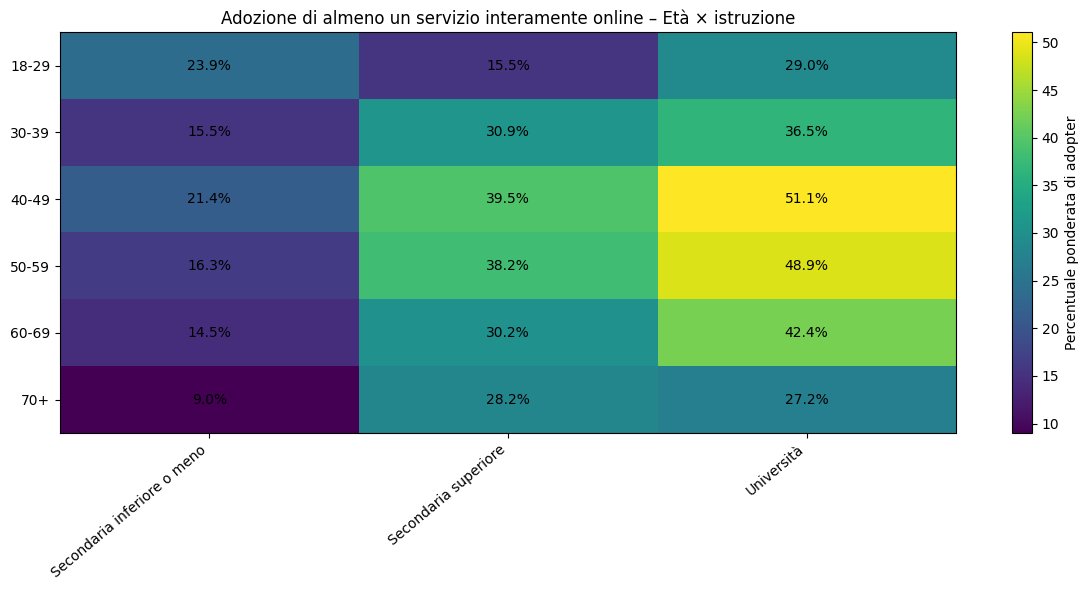

In [65]:
save_annotated_heatmap(
    table=adoption_interaction_pivot,

    title=(
        "Adozione di almeno un servizio "
        "interamente online – Età × istruzione"
    ),

    colorbar_label=(
        "Percentuale ponderata di adopter"
    ),

    output_path=(
        FIGURES_DIR
        / "digital_adoption_age_education.png"
    )
)

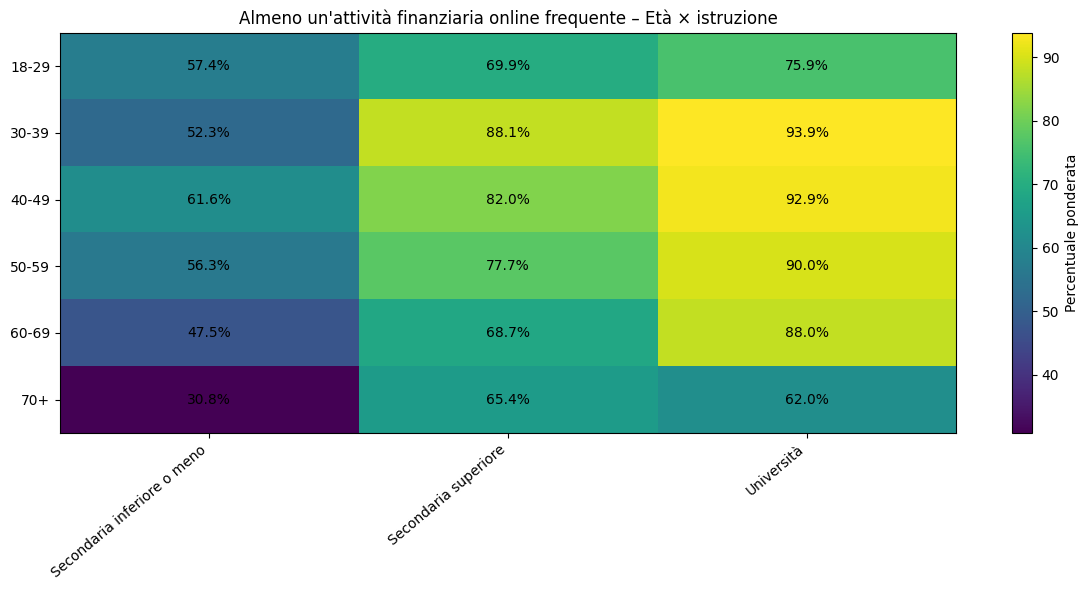

In [66]:
save_annotated_heatmap(
    table=frequent_interaction_pivot,

    title=(
        "Almeno un'attività finanziaria online "
        "frequente – Età × istruzione"
    ),

    colorbar_label=(
        "Percentuale ponderata"
    ),

    output_path=(
        FIGURES_DIR
        / "frequent_qp9_age_education.png"
    )
)

per regressione logistica categorie di riferimento:
- 40–49 anni;
- secondaria superiore.

In [69]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [70]:
model_df = connected.dropna(
    subset=[
        "digital_adoption",
        "age_group",
        "education_model",
        "wght"
    ]
).copy()

# Normalizzazione dei pesi: media uguale a 1
model_df["wght_normalized"] = (
    model_df["wght"]
    / model_df["wght"].mean()
)

print("Osservazioni nel modello:", len(model_df))

Osservazioni nel modello: 4249


In [71]:
formula = """
digital_adoption
~ C(
    age_group,
    Treatment(reference="40-49")
)
+ C(
    education_model,
    Treatment(reference="Secondaria superiore")
)
"""

weighted_logit_model = smf.glm(
    formula=formula,
    data=model_df,
    family = sm.families.Binomial(),
    freq_weights=model_df["wght_normalized"]
).fit(
    cov_type="HC1"
)

print(
    weighted_logit_model.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:       digital_adoption   No. Observations:                 4249
Model:                            GLM   Df Residuals:                     4241
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2509.5
Date:                Thu, 30 Jul 2026   Deviance:                       5019.0
Time:                        16:33:23   Pearson chi2:                 4.28e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05654
Covariance Type:                  HC1                                         
                                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

questi sotto non so qanto ci interessino visto che la maggior parte sono già qui sopra, aggiunge solo odds ratio e le colonnew dopo

In [73]:
model_coefficients = pd.DataFrame({
    "coefficient":
        weighted_logit_model.params,

    "standard_error":
        weighted_logit_model.bse,

    "z_value":
        weighted_logit_model.tvalues,

    "p_value":
        weighted_logit_model.pvalues
})

confidence_intervals = (
    weighted_logit_model
    .conf_int()
)

model_coefficients["ci_lower"] = (
    confidence_intervals[0]
)

model_coefficients["ci_upper"] = (
    confidence_intervals[1]
)

model_coefficients["odds_ratio"] = np.exp(
    model_coefficients["coefficient"]
)

model_coefficients["or_ci_lower"] = np.exp(
    model_coefficients["ci_lower"]
)

model_coefficients["or_ci_upper"] = np.exp(
    model_coefficients["ci_upper"]
)

display(
    model_coefficients.round(4)
)

,coefficient,standard_error,z_value,p_value,ci_lower,ci_upper,odds_ratio,or_ci_lower,or_ci_upper
Intercept,-0.4080,0.0787,-5.1824,0.0000,-0.5624,-0.2537,0.6650,0.5699,0.7759
"C(age_group, Treatment(reference=""40-49""))[T.18-29]",-0.9833,0.1237,-7.9487,0.0000,-1.2257,-0.7408,0.3741,0.2935,0.4767
"C(age_group, Treatment(reference=""40-49""))[T.30-39]",-0.4677,0.1031,-4.5381,0.0000,-0.6697,-0.2657,0.6264,0.5119,0.7667
"C(age_group, Treatment(reference=""40-49""))[T.50-59]",-0.1025,0.1003,-1.0222,0.3067,-0.2991,0.0941,0.9025,0.7415,1.0986
"C(age_group, Treatment(reference=""40-49""))[T.60-69]",-0.4270,0.1188,-3.5946,0.0003,-0.6598,-0.1942,0.6525,0.5169,0.8235
"C(age_group, Treatment(reference=""40-49""))[T.70+]",-0.7341,0.1509,-4.8650,0.0000,-1.0298,-0.4383,0.4800,0.3571,0.6451
"C(education_model, Treatment(reference=""Secondaria superiore""))[T.Secondaria inferiore o meno]",-0.8688,0.1110,-7.8270,0.0000,-1.0864,-0.6513,0.4194,0.3374,0.5214
"C(education_model, Treatment(reference=""Secondaria superiore""))[T.Università]",0.4175,0.0778,5.3678,0.0000,0.2651,0.5699,1.5182,1.3035,1.7682


In [74]:
def adjusted_probabilities(
    model,
    data,
    variable,
    categories
):

    records = []

    original_categories = (
        data[variable]
        .cat
        .categories
    )

    for category in categories:

        hypothetical_data = data.copy()

        hypothetical_data[variable] = pd.Categorical(
            [category] * len(hypothetical_data),
            categories=original_categories,
            ordered=True
        )

        predicted_probability = model.predict(
            hypothetical_data
        )

        weighted_probability = np.average(
            predicted_probability,
            weights=hypothetical_data["wght"]
        )

        records.append({
            "category": category,
            "adjusted_probability_pct":
                weighted_probability * 100
        })

    return pd.DataFrame(records)

In [75]:
adjusted_age = adjusted_probabilities(
    model=weighted_logit_model,
    data=model_df,
    variable="age_group",
    categories=age_order
)

display(adjusted_age.round(2))

,category,adjusted_probability_pct
0,18-29,19.88
1,30-39,29.07
2,40-49,39.17
3,50-59,36.84
4,60-69,29.89
5,70+,24.04


In [77]:
adjusted_education = adjusted_probabilities(
    model=weighted_logit_model,
    data=model_df,
    variable="education_model",
    categories=education_order
)

display(adjusted_education.round(2))

,category,adjusted_probability_pct
0,Secondaria inferiore o meno,16.34
1,Secondaria superiore,31.43
2,Università,40.79


In [78]:
def plot_adjusted_probabilities(
    results,
    title,
    output_path
):

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        results["category"],
        results["adjusted_probability_pct"]
    )

    ax.set_title(title)
    ax.set_ylabel(
        "Probabilità aggiustata (%)"
    )
    ax.set_ylim(0, 100)

    ax.tick_params(
        axis="x",
        rotation=30
    )

    ax.bar_label(
        bars,
        fmt="%.1f%%",
        padding=3
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

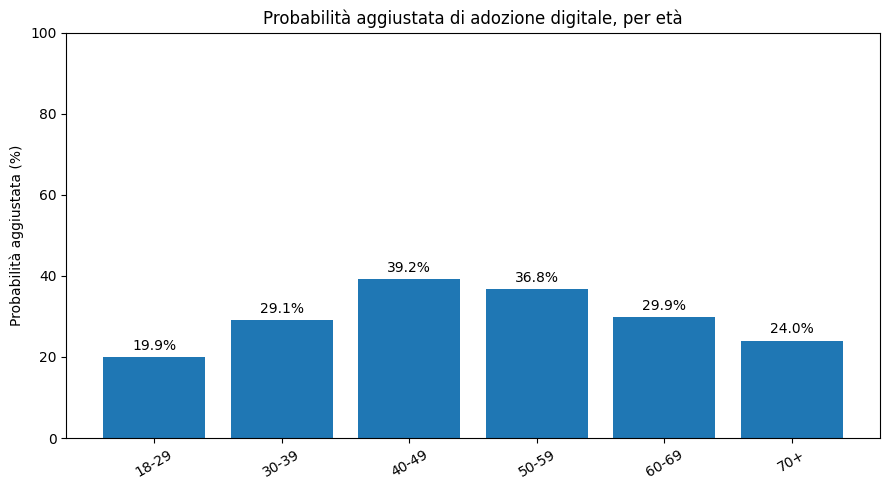

In [79]:
plot_adjusted_probabilities(
    results=adjusted_age,

    title=(
        "Probabilità aggiustata di adozione "
        "digitale, per età"
    ),

    output_path=(
        FIGURES_DIR
        / "adjusted_adoption_by_age.png"
    )
)

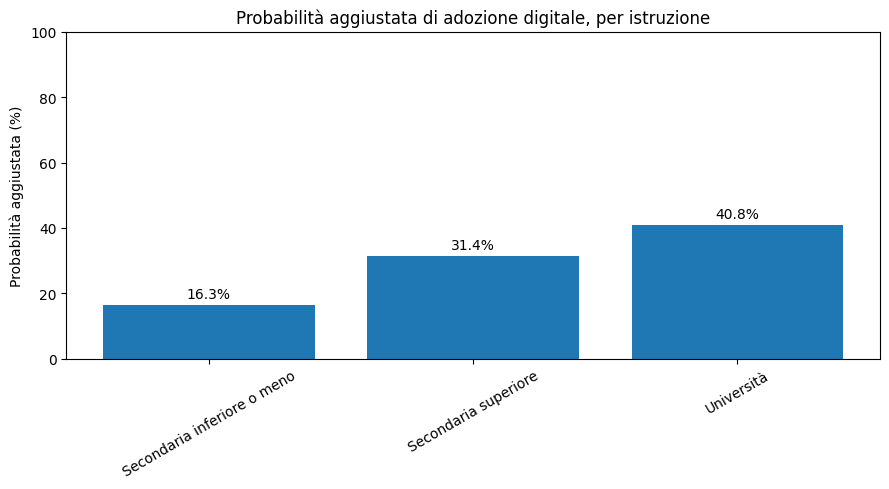

In [80]:
plot_adjusted_probabilities(
    results=adjusted_education,

    title=(
        "Probabilità aggiustata di adozione "
        "digitale, per istruzione"
    ),

    output_path=(
        FIGURES_DIR
        / "adjusted_adoption_by_education.png"
    )
)